# Entregable 2: Windows Defender detector

## 1. Importación de librerías, primera visualización de dataframe, comprobación de duplicados y target = "HasDetections"

In [158]:
# IMPORTAMOS LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler

In [ ]:
#csv_path = r"D:\Documentos\Nuclio\Entregable_2\sample_mmp.csv"
#csv_path = r"C:\Users\jonmi\Documents\Nuclio\nuclio-datascience_AI\Entregable_2\sample_mmp.csv"
csv_path = r"C:\Users\JGarcia94\OneDrive - Lear Corporation\Documents\GITHub_Repository\nuclio-datascience_AI\Entregable_2\sample_mmp.csv"
df = pd.read_csv(csv_path, dtype={"PuaMode": 'category', "Census_ProcessorClass": "category"})

In [160]:
df.shape

(500000, 84)

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 84 columns):
 #   Column                                             Non-Null Count   Dtype   
---  ------                                             --------------   -----   
 0   Unnamed: 0                                         500000 non-null  int64   
 1   MachineIdentifier                                  500000 non-null  object  
 2   ProductName                                        500000 non-null  object  
 3   EngineVersion                                      500000 non-null  object  
 4   AppVersion                                         500000 non-null  object  
 5   AvSigVersion                                       500000 non-null  object  
 6   IsBeta                                             500000 non-null  int64   
 7   RtpStateBitfield                                   498168 non-null  float64 
 8   IsSxsPassiveMode                                   500000 non-nu

In [162]:
df.head().T

,0,1,2,3,4
Unnamed: 0,8427007,8829090,2731904,1359513,236059
MachineIdentifier,f1cd864e97bae82bdf96523e1a539121,fd5ba6f5b75325ec0423a6c67cc75942,4e628391e7cc7c482fb3286f486dbd25,270a2e9d028144a4df12a9e3da79fba5,06ca8fa8d32c2abdc5b3577d676b3269
ProductName,win8defender,win8defender,win8defender,win8defender,win8defender
EngineVersion,1.1.15100.1,1.1.15100.1,1.1.15100.1,1.1.15200.1,1.1.15200.1
AppVersion,4.18.1807.18075,4.18.1807.18075,4.9.10586.1106,4.18.1807.18075,4.18.1807.18075
AvSigVersion,1.273.1234.0,1.273.1282.0,1.273.781.0,1.275.1639.0,1.275.511.0
IsBeta,0,0,0,0,0
RtpStateBitfield,7.0,7.0,7.0,7.0,7.0
IsSxsPassiveMode,0,0,0,0,0
DefaultBrowsersIdentifier,NaN,NaN,NaN,NaN,NaN


In [163]:
pd.set_option('display.max_rows', 100)

In [164]:
numeric_describe = df.describe(include='number').T
numeric_describe

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,500000.0,4.458888e+06,2.575619e+06,2.0,2227692.50,4461367.5,6.690936e+06,8.921471e+06
IsBeta,500000.0,2.000000e-06,1.414214e-03,0.0,0.00,0.0,0.000000e+00,1.000000e+00
RtpStateBitfield,498168.0,6.846207e+00,1.023049e+00,0.0,7.00,7.0,7.000000e+00,3.500000e+01
IsSxsPassiveMode,500000.0,1.724200e-02,1.301720e-01,0.0,0.00,0.0,0.000000e+00,1.000000e+00
DefaultBrowsersIdentifier,24061.0,1.652825e+03,1.004754e+03,1.0,788.00,1632.0,2.381000e+03,3.209000e+03
AVProductStatesIdentifier,498062.0,4.785091e+04,1.402309e+04,3.0,49480.00,53447.0,5.344700e+04,7.049200e+04
AVProductsInstalled,498062.0,1.326763e+00,5.229999e-01,1.0,1.00,1.0,2.000000e+00,5.000000e+00
AVProductsEnabled,498062.0,1.020714e+00,1.666080e-01,0.0,1.00,1.0,1.000000e+00,4.000000e+00
HasTpm,500000.0,9.878160e-01,1.097068e-01,0.0,1.00,1.0,1.000000e+00,1.000000e+00
CountryIdentifier,500000.0,1.080375e+02,6.306854e+01,1.0,51.00,97.0,1.620000e+02,2.220000e+02


In [165]:
object_describe = df.describe(include='object').T
object_describe

,count,unique,top,freq
MachineIdentifier,500000,500000,fba7138931e22f004ee389c236b98254,1
ProductName,500000,3,win8defender,494604
EngineVersion,500000,53,1.1.15200.1,216491
AppVersion,500000,95,4.18.1807.18075,288809
AvSigVersion,500000,6455,1.273.1420.0,5771
Platform,500000,4,windows10,483048
Processor,500000,3,x64,454423
OsVer,500000,21,10.0.0.0,483830
OsPlatformSubRelease,500000,9,rs4,220779
OsBuildLab,499999,453,17134.1.amd64fre.rs4_release.180410-1804,206436


In [166]:
df[df.duplicated(keep="first")]

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections


In [167]:
df.isna().sum()

Unnamed: 0                                                0
MachineIdentifier                                         0
ProductName                                               0
EngineVersion                                             0
AppVersion                                                0
AvSigVersion                                              0
IsBeta                                                    0
RtpStateBitfield                                       1832
IsSxsPassiveMode                                          0
DefaultBrowsersIdentifier                            475939
AVProductStatesIdentifier                              1938
AVProductsInstalled                                    1938
AVProductsEnabled                                      1938
HasTpm                                                    0
CountryIdentifier                                         0
CityIdentifier                                        18240
OrganizationIdentifier                  

In [168]:
df.drop(columns = ['Unnamed: 0', 'MachineIdentifier'], axis=1, inplace=True)

### 1.1. Definición de target y ajuste de tipo de variables

In [169]:
target = "HasDetections"

## 2. Separación validación, test y train

Se empleará el método stratification para mantener la distribución del target ya que está balanceado

In [170]:
from sklearn.model_selection import train_test_split

X = df.drop(target, axis=1)
y = df[target]

# Step 1: Create Validation set (15%)
X_temp, X_val, y_temp, y_val = train_test_split(
    X, y,
    test_size=75000,  # 15% of total
    stratify=y,
    random_state=42
)

# Step 2: Create TEST set (15% of total)

X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp,
    test_size=75000, # 15% of total
    stratify=y_temp,
    random_state=42
)

In [171]:
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Train: HasDetections
0    0.500094
1    0.499906
Name: proportion, dtype: float64
Val: HasDetections
0    0.500093
1    0.499907
Name: proportion, dtype: float64
Test: HasDetections
0    0.500093
1    0.499907
Name: proportion, dtype: float64


In [172]:
np.save("train_idx.npy", X_train.index)
np.save("val_idx.npy", X_val.index)
np.save("test_idx.npy", X_test.index)

In [173]:
df_train = X_train.copy()
df_train[target] = y_train

## 3. EDA + Gestión de nulos

In [174]:
class EDAInspector:
    #DecisionTree version
    def __init__(self, df):
        self.df = df.copy()
        self.refresh_types()
    
        # Lists to track treated columns
        self.fill_constant_list = []
        self.fill_mean_list = []
        self.fill_median_list = []
        self.fill_missing_list = []
        #self.missing_indicator_list = []
        self.drop_columns = []
        #self.dropped_nanRows_columns = []
        
    # ----------------------------
    # TYPE REFRESH
    # ----------------------------
    
    def refresh_types(self):
        self.n_rows = len(self.df)
        self.numeric_cols = self.df.select_dtypes(include=np.number).columns.tolist()
        self.object_cols = self.df.select_dtypes(include=["object"]).columns.tolist()
        self.category_cols = self.df.select_dtypes(include=["category"]).columns.tolist()
        self.bool_cols = self.df.select_dtypes(include=["bool"]).columns.tolist()
    
    @property #se emplea como propiedad para que se ejecute automáticamente al acceder a ella, sin necesidad de llamarla como método
    def high_cardinality_cols(self):

        cat_cols = self.object_cols + self.category_cols

        unique_counts = self.df[cat_cols].nunique()

        return unique_counts[unique_counts > 100].index.tolist()
    
    # ----------------------------
    # NUMERIC SUMMARY
    # ----------------------------
    
    def numeric_summary(self):
        
        summary = pd.DataFrame({
            "dtype": self.df[self.numeric_cols].dtypes,
            "unique_values": self.df[self.numeric_cols].nunique(),
            "pct_unique": self.df[self.numeric_cols].nunique() / self.n_rows * 100,
            "null_pct": self.df[self.numeric_cols].isnull().mean() * 100,
            "min": self.df[self.numeric_cols].min(),
            "max": self.df[self.numeric_cols].max()
        })
        
        summary["possible_id"] = summary["pct_unique"] > 90
        
        summary["likely_categorical"] = (
            (summary["unique_values"] < 60) &
            (summary["pct_unique"] < 5)
        )
        
        # Store likely_categorical columns as a list for easy access
        self.likely_categorical_cols = summary[summary["likely_categorical"]].index.tolist()
        
        return summary.sort_values("pct_unique", ascending=False)
    
    
    # ----------------------------
    # CATEGORICAL SUMMARY
    # ----------------------------
    
    def categorical_summary(self):

        cat_cols = self.object_cols + self.category_cols

        summary = pd.DataFrame({
            "dtype": self.df[cat_cols].dtypes,
            "unique_values": self.df[cat_cols].nunique(),
            "pct_unique": self.df[cat_cols].nunique() / self.n_rows * 100,
            "null_pct": self.df[cat_cols].isnull().mean() * 100
        })

        summary["high_cardinality"] = summary.index.isin(self.high_cardinality_cols)

        return summary.sort_values("unique_values", ascending=False)
    
    # ----------------------------
    # Identifier/Version etc DETECTOR in numeric columns
    # ---------------------------- 
    
    def detect_identifier_columns(self, keywords=None):
    
        if keywords is None:
            keywords = ["identifier"]
        
        self.identifier_cols = [
            col for col in self.numeric_cols
            if any(k in col.lower() for k in keywords)
        ]
        
        print(f"Detected {len(self.identifier_cols)} identifier columns:")
        #print(self.identifier_cols)
        
        return self.identifier_cols
 
    
    # ----------------------------
    # CONVERT NUMERIC → CATEGORY
    # ----------------------------
    
    def convert_to_category(self, columns, verbose=True):
        
        if isinstance(columns, str):
            columns = [columns]
        
        for col in columns:
            if col in self.df.columns:
                self.df[col] = self.df[col].astype("category")
        
        self.refresh_types()
        
        if verbose:
            print(len(columns), " converted to category:", columns)
    
    
    # ----------------------------
    # CONVERT TO NUMERIC
    # ----------------------------
    
    def convert_to_numeric(self, columns, verbose=True):
        
        if isinstance(columns, str):
            columns = [columns]
        
        for col in columns:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors="coerce")
        
        self.refresh_types()
        
        if verbose:
            print(len(columns), " converted to numeric:", columns)



    def null_summary(self, only_nulls = False):
        self.summary = pd.DataFrame({
            "dtype": self.df.dtypes,
            "null_count": self.df.isnull().sum(),
            "pct_nulls": self.df.isnull().mean() * 100,
            "unique_values": self.df.nunique(),
            "pct_unique": self.df.nunique() / self.n_rows * 100
        })
        
        result = self.summary.sort_values("pct_nulls", ascending=False)
        
        if only_nulls:
            result = result[result["null_count"]>0]
            
        return result
        
    def droppable_columns(
        self,
        null_high_thresh=95,
        null_low_thresh=0.5,
        cardinality_threshold=90
    ):
        """
        Classifies columns into:
        - high null percentage → drop
        - high cardinality → drop
        - low nulls → fill (categorical → 'Missing', numeric → median)
        """

        null_sum = self.null_summary()

        # -------------------------
        # 1. HIGH NULL COLUMNS → DROP
        # -------------------------
        high_null_cols = null_sum[null_sum["pct_nulls"] > null_high_thresh].index.tolist()

        # -------------------------
        # 2. HIGH CARDINALITY → DROP
        # -------------------------
        high_cardinality_cols = null_sum[null_sum["pct_unique"] > cardinality_threshold].index.tolist()

        # -------------------------
        # 3. LOW NULL COLUMNS → FILL
        # -------------------------
        low_null_cols = null_sum[
            (null_sum["pct_nulls"] > 0) &
            (null_sum["pct_nulls"] < null_low_thresh)
        ].index.tolist()

        # Split low-null columns by dtype
        low_null_categorical = [c for c in low_null_cols if c in self.object_cols + self.category_cols]
        low_null_numeric = [c for c in low_null_cols if c in self.numeric_cols]

        # -------------------------
        # 4. Apply actions
        # -------------------------

        # Drop high-null and high-cardinality columns
        cols_to_drop = high_null_cols + high_cardinality_cols
        if cols_to_drop:
            self.drop_columns.extend(cols_to_drop)

        # Fill categorical with "Missing" because DecisionTree handles it
        for col in low_null_categorical:
            self.fill_missing_list.append(col)

        # Fill numeric with median
        for col in low_null_numeric:
            self.fill_median_list.append(col)

        # -------------------------
        # 5. Logging
        # -------------------------
        print(f"{len(high_null_cols)} columns dropped due to high null percentage: {high_null_cols}")
        print(f"{len(high_cardinality_cols)} columns dropped due to high cardinality: {high_cardinality_cols}")
        print(f"{len(low_null_categorical)} categorical columns added to fill_missing_list : {low_null_categorical}")
        print(f"{len(low_null_numeric)} numeric columns added to fill_median_list: {low_null_numeric}")

        self.refresh_types()
    
    
    def imputation_summary(self):
        """
        Build a summary DataFrame showing:
        - columns dropped
        - columns filled with constant / mean / median
        - columns still containing nulls (not treated)
        - remaining untouched columns
        """

        # Ensure lists are flat
        drop = sorted(set(self.drop_columns))
        fill_constant = sorted(set(self.fill_constant_list))
        fill_mean = sorted(set(self.fill_mean_list))
        fill_median = sorted(set(self.fill_median_list))
        fill_missing = sorted(set(self.fill_missing_list))

        # Columns with nulls that were NOT treated
        treated = set(drop + fill_constant + fill_mean + fill_median + fill_missing)
        null_cols = self.df.columns[self.df.isnull().any()].tolist()
        self.remaining_null_cols = sorted(set(null_cols) - treated)

        # Untouched columns = all columns - treated - remaining_null_cols
        self.untouched = sorted(set(self.df.columns) - treated - set(self.remaining_null_cols))

        # Build dictionary
        summary_dict = {
            "drop_columns": drop,
            "fill_constant": fill_constant,
            "fill_mean": fill_mean,
            "fill_median": fill_median,
            "fill_missing": fill_missing,
            "remaining_null_columns": self.remaining_null_cols,
            "untouched_columns": self.untouched
        }

        # Build DataFrame
        rows = []
        for category, cols in summary_dict.items():
            if cols:
                dtypes = sorted({str(self.df[col].dtype) for col in cols if col in self.df.columns})
            else:
                dtypes = []

            rows.append({
                "category": category,
                "n_columns": len(cols),
                "columns": cols,
                "dtypes": dtypes
            })

        return pd.DataFrame(rows)

        
    def get_data(self):
        return self.df




### 3.1. Inspector1 creation for first EDA

In [175]:
inspector1 = EDAInspector(df_train)

In [176]:
inspector1.numeric_summary()

,dtype,unique_values,pct_unique,null_pct,min,max,possible_id,likely_categorical
Census_SystemVolumeTotalCapacity,float64,112810,32.231429,0.595143,9689.0,2.859558e+07,False,False
Census_OEMModelIdentifier,float64,33296,9.513143,1.150000,22.0,3.454930e+05,False,False
CityIdentifier,float64,31181,8.908857,3.626000,7.0,1.679580e+05,False,False
Census_FirmwareVersionIdentifier,float64,20897,5.970571,1.812857,10.0,7.209100e+04,False,False
AVProductStatesIdentifier,float64,4466,1.276000,0.386000,3.0,7.049200e+04,False,False
Census_InternalBatteryNumberOfCharges,float64,4031,1.151714,3.003143,0.0,4.294967e+09,False,False
Census_ProcessorModelIdentifier,float64,2127,0.607714,0.469143,19.0,4.472000e+03,False,False
Census_OEMNameIdentifier,float64,1406,0.401714,1.068571,74.0,6.143000e+03,False,False
Census_PrimaryDiskTotalCapacity,float64,906,0.258857,0.595143,10240.0,2.859591e+07,False,False
Census_InternalPrimaryDiagonalDisplaySizeInInches,float64,483,0.138000,0.534000,4.9,1.420000e+02,False,False


In [177]:
inspector1.likely_categorical_cols

['IsBeta',
 'RtpStateBitfield',
 'IsSxsPassiveMode',
 'AVProductsInstalled',
 'AVProductsEnabled',
 'HasTpm',
 'OrganizationIdentifier',
 'OsBuild',
 'OsSuite',
 'IsProtected',
 'AutoSampleOptIn',
 'SMode',
 'Firewall',
 'UacLuaenable',
 'Census_ProcessorCoreCount',
 'Census_ProcessorManufacturerIdentifier',
 'Census_HasOpticalDiskDrive',
 'Census_OSBuildNumber',
 'Census_OSInstallLanguageIdentifier',
 'Census_IsPortableOperatingSystem',
 'Census_IsFlightingInternal',
 'Census_IsFlightsDisabled',
 'Census_ThresholdOptIn',
 'Census_IsSecureBootEnabled',
 'Census_IsWIMBootEnabled',
 'Census_IsVirtualDevice',
 'Census_IsTouchEnabled',
 'Census_IsPenCapable',
 'Census_IsAlwaysOnAlwaysConnectedCapable',
 'Wdft_IsGamer',
 'Wdft_RegionIdentifier',
 'HasDetections']

In [178]:
inspector1.convert_to_category(inspector1.likely_categorical_cols)

32  converted to category: ['IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode', 'AVProductsInstalled', 'AVProductsEnabled', 'HasTpm', 'OrganizationIdentifier', 'OsBuild', 'OsSuite', 'IsProtected', 'AutoSampleOptIn', 'SMode', 'Firewall', 'UacLuaenable', 'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier', 'Census_HasOpticalDiskDrive', 'Census_OSBuildNumber', 'Census_OSInstallLanguageIdentifier', 'Census_IsPortableOperatingSystem', 'Census_IsFlightingInternal', 'Census_IsFlightsDisabled', 'Census_ThresholdOptIn', 'Census_IsSecureBootEnabled', 'Census_IsWIMBootEnabled', 'Census_IsVirtualDevice', 'Census_IsTouchEnabled', 'Census_IsPenCapable', 'Census_IsAlwaysOnAlwaysConnectedCapable', 'Wdft_IsGamer', 'Wdft_RegionIdentifier', 'HasDetections']


In [179]:
inspector1.detect_identifier_columns()

Detected 13 identifier columns:


['DefaultBrowsersIdentifier',
 'AVProductStatesIdentifier',
 'CountryIdentifier',
 'CityIdentifier',
 'GeoNameIdentifier',
 'LocaleEnglishNameIdentifier',
 'IeVerIdentifier',
 'Census_OEMNameIdentifier',
 'Census_OEMModelIdentifier',
 'Census_ProcessorModelIdentifier',
 'Census_OSUILocaleIdentifier',
 'Census_FirmwareManufacturerIdentifier',
 'Census_FirmwareVersionIdentifier']

In [180]:
inspector1.convert_to_category(inspector1.identifier_cols)

13  converted to category: ['DefaultBrowsersIdentifier', 'AVProductStatesIdentifier', 'CountryIdentifier', 'CityIdentifier', 'GeoNameIdentifier', 'LocaleEnglishNameIdentifier', 'IeVerIdentifier', 'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier', 'Census_ProcessorModelIdentifier', 'Census_OSUILocaleIdentifier', 'Census_FirmwareManufacturerIdentifier', 'Census_FirmwareVersionIdentifier']


In [181]:
inspector1.droppable_columns()

3 columns dropped due to high null percentage: ['PuaMode', 'Census_ProcessorClass', 'DefaultBrowsersIdentifier']
0 columns dropped due to high cardinality: []
14 categorical columns added to fill_missing_list : ['Census_ProcessorModelIdentifier', 'Census_ProcessorManufacturerIdentifier', 'Census_ProcessorCoreCount', 'AVProductsEnabled', 'AVProductsInstalled', 'AVProductStatesIdentifier', 'IsProtected', 'RtpStateBitfield', 'Census_IsVirtualDevice', 'Census_PrimaryDiskTypeName', 'UacLuaenable', 'Census_ChassisTypeName', 'GeoNameIdentifier', 'OsBuildLab']
0 numeric columns added to fill_median_list: []


In [182]:
inspector1.numeric_summary()

,dtype,unique_values,pct_unique,null_pct,min,max,possible_id,likely_categorical
Census_SystemVolumeTotalCapacity,float64,112810,32.231429,0.595143,9689.0,2.859558e+07,False,False
Census_InternalBatteryNumberOfCharges,float64,4031,1.151714,3.003143,0.0,4.294967e+09,False,False
Census_PrimaryDiskTotalCapacity,float64,906,0.258857,0.595143,10240.0,2.859591e+07,False,False
Census_InternalPrimaryDiagonalDisplaySizeInInches,float64,483,0.138000,0.534000,4.9,1.420000e+02,False,False
Census_TotalPhysicalRAM,float64,449,0.128286,0.896857,512.0,3.932160e+05,False,False
Census_InternalPrimaryDisplayResolutionVertical,float64,420,0.120000,0.533429,-1.0,4.320000e+03,False,False
Census_InternalPrimaryDisplayResolutionHorizontal,float64,374,0.106857,0.533429,-1.0,1.152000e+04,False,False
Census_OSBuildRevision,int64,237,0.067714,0.000000,0.0,1.906900e+04,False,False


In [183]:
#Census_InternalBatteryNumberOfCharges correlation check, drop suspicious
inspector1.df[target].corr(inspector1.df.Census_InternalBatteryNumberOfCharges)

np.float64(0.01995231376898978)

In [184]:
inspector1.categorical_summary()

,dtype,unique_values,pct_unique,null_pct,high_cardinality
Census_OEMModelIdentifier,category,33296,9.513143,1.150000,True
CityIdentifier,category,31181,8.908857,3.626000,True
Census_FirmwareVersionIdentifier,category,20897,5.970571,1.812857,True
AvSigVersion,object,5925,1.692857,0.000000,True
AVProductStatesIdentifier,category,4466,1.276000,0.386000,True
Census_ProcessorModelIdentifier,category,2127,0.607714,0.469143,True
Census_OEMNameIdentifier,category,1406,0.401714,1.068571,True
DefaultBrowsersIdentifier,category,469,0.134000,95.179143,True
OsBuildLab,object,431,0.123143,0.000286,True
Census_OSVersion,object,292,0.083429,0.000000,True


In [185]:
inspector1.imputation_summary()

,category,n_columns,columns,dtypes
0,drop_columns,3,"[Census_ProcessorClass, DefaultBrowsersIdentif...",[category]
1,fill_constant,0,[],[]
2,fill_mean,0,[],[]
3,fill_median,0,[],[]
4,fill_missing,14,"[AVProductStatesIdentifier, AVProductsEnabled,...","[category, object]"
5,remaining_null_columns,26,"[Census_FirmwareManufacturerIdentifier, Census...","[category, float64, object]"
6,untouched_columns,39,"[AppVersion, AutoSampleOptIn, AvSigVersion, Ce...","[category, int64, object]"


### 3.2. Check signal function

In [186]:
#This functions helps us check the impact of a column on the target variable, both for null values and for the different values of the column.

def check_signal(df, col, target=target):
    print("Value counts:")
    print(df[col].value_counts(dropna=False, normalize=True))
    
    print("\nNull impact:")
    print(df.groupby(df[col].isnull())[target].mean())
    
    print("\nValue impact:")
    print(df.groupby(col)[target].mean().sort_values())

### 3.3. Columnas con >30% y <95% nulos

#### Census_IsFlightingInternal: it is a property of the Operating System's "Device Census" service, not a setting you toggle to change how Defender works, due it's high null pct and little difference in target mean between '1' (2 values), '0' and 'missing' we drop it.

In [187]:
check_signal(df_train, 'Census_IsFlightingInternal')

Value counts:
Census_IsFlightingInternal
NaN    0.830383
0.0    0.169614
1.0    0.000003
Name: proportion, dtype: float64

Null impact:
Census_IsFlightingInternal
False    0.485935
True     0.502759
Name: HasDetections, dtype: float64

Value impact:
Census_IsFlightingInternal
1.0    0.000000
0.0    0.485943
Name: HasDetections, dtype: float64


In [188]:
inspector1.drop_columns.append('Census_IsFlightingInternal')

#### Drop Census_InternalBatteryType: self explanatory. Categorical variable that will have the Nan's as 'missing' category. Pero se puede eliminar (tipo de batería no indicará malware)

In [189]:
#Add missing category
df_train['Census_InternalBatteryType'].value_counts(dropna = False, normalize = True)

Census_InternalBatteryType
NaN     0.711549
lion    0.226729
li-i    0.027700
#       0.020306
lip     0.006626
liio    0.003537
li p    0.000969
li      0.000734
nimh    0.000577
real    0.000311
bq20    0.000294
pbac    0.000257
vbox    0.000186
lgi0    0.000051
unkn    0.000040
lipo    0.000034
lhp0    0.000023
ram     0.000014
4cel    0.000011
lipp    0.000009
ithi    0.000009
batt    0.000009
bad     0.000006
a132    0.000006
virt    0.000006
icp3    0.000003
3ion    0.000003
lgl0    0.000003
Name: proportion, dtype: float64

In [190]:
check_signal(df_train, 'Census_InternalBatteryType')

Value counts:
Census_InternalBatteryType
NaN     0.711549
lion    0.226729
li-i    0.027700
#       0.020306
lip     0.006626
liio    0.003537
li p    0.000969
li      0.000734
nimh    0.000577
real    0.000311
bq20    0.000294
pbac    0.000257
vbox    0.000186
lgi0    0.000051
unkn    0.000040
lipo    0.000034
lhp0    0.000023
ram     0.000014
4cel    0.000011
lipp    0.000009
ithi    0.000009
batt    0.000009
bad     0.000006
a132    0.000006
virt    0.000006
icp3    0.000003
3ion    0.000003
lgl0    0.000003
Name: proportion, dtype: float64

Null impact:
Census_InternalBatteryType
False    0.485331
True     0.505814
Name: HasDetections, dtype: float64

Value impact:
Census_InternalBatteryType
3ion    0.000000
4cel    0.000000
batt    0.000000
virt    0.000000
ram     0.200000
vbox    0.230769
lhp0    0.250000
bq20    0.252427
ithi    0.333333
lipo    0.416667
nimh    0.420792
li      0.443580
liio    0.464459
pbac    0.466667
lion    0.481104
li-i    0.483136
li p    0.486726
a132  

In [191]:
inspector1.drop_columns.append('Census_InternalBatteryType')

#### Census_ThresholdOptIn can be dropped, it is only an indicator of data collection not a security indicator
Is an internal registry value used by Windows to manage your participation in Windows Insider "Census" data collection. It is not a standard security setting within the Windows Defender/Security interface that you "opt-in" to for better protection.
Instead, this value tracks whether your device meets the "threshold" for certain diagnostic and telemetry reporting required for Insider preview builds of Windows.

In [192]:
check_signal(df_train, 'Census_ThresholdOptIn')

Value counts:
Census_ThresholdOptIn
NaN    0.636417
0.0    0.363489
1.0    0.000094
Name: proportion, dtype: float64

Null impact:
Census_ThresholdOptIn
False    0.490020
True     0.505553
Name: HasDetections, dtype: float64

Value impact:
Census_ThresholdOptIn
0.0    0.490013
1.0    0.515152
Name: HasDetections, dtype: float64


In [193]:
inspector1.drop_columns.append('Census_ThresholdOptIn')

#### Census_IsWIMBootEnabled can be dropped as there is only missing or '0' values and there is no meaningful separation when referred to the target

In [194]:
check_signal(df_train, 'Census_IsWIMBootEnabled')

Value counts:
Census_IsWIMBootEnabled
NaN    0.635589
0.0    0.364411
Name: proportion, dtype: float64

Null impact:
Census_IsWIMBootEnabled
False    0.490027
True     0.505570
Name: HasDetections, dtype: float64

Value impact:
Census_IsWIMBootEnabled
0.0    0.490027
Name: HasDetections, dtype: float64


In [195]:
inspector1.drop_columns.append('Census_IsWIMBootEnabled')

#### SmartScreen. Categorical variable that will have the Nan's as 'missing' category.

In [196]:
#Add missing category
df_train['SmartScreen'].value_counts(dropna = False, normalize = True)

SmartScreen
RequireAdmin    0.482746
NaN             0.357580
ExistsNotSet    0.117029
Off             0.020803
Warn            0.015063
Prompt          0.003934
Block           0.002517
off             0.000140
On              0.000106
&#x02;          0.000037
&#x01;          0.000026
on              0.000017
requireadmin    0.000003
Name: proportion, dtype: float64

In [197]:
inspector1.fill_missing_list.append('SmartScreen')

#### OrganizationIdentifier:  ID for the organization the machine belongs in, organization ID is mapped to both specific companies and broad industries
Column will be treated as categorical and Nan values will turn to 'missing'.

In [198]:
check_signal(df_train, 'OrganizationIdentifier')

Value counts:
OrganizationIdentifier
27.0    0.469929
NaN     0.309394
18.0    0.197289
48.0    0.007357
50.0    0.005120
11.0    0.002074
37.0    0.002066
49.0    0.001414
46.0    0.001277
14.0    0.000534
32.0    0.000437
36.0    0.000423
33.0    0.000366
52.0    0.000337
2.0     0.000309
5.0     0.000209
40.0    0.000191
28.0    0.000183
4.0     0.000160
10.0    0.000143
51.0    0.000103
1.0     0.000089
20.0    0.000071
8.0     0.000066
47.0    0.000057
3.0     0.000051
22.0    0.000046
6.0     0.000043
39.0    0.000043
31.0    0.000037
21.0    0.000029
16.0    0.000023
42.0    0.000023
19.0    0.000020
44.0    0.000017
7.0     0.000017
29.0    0.000014
26.0    0.000011
43.0    0.000009
45.0    0.000006
41.0    0.000006
35.0    0.000003
25.0    0.000003
23.0    0.000003
Name: proportion, dtype: float64

Null impact:
OrganizationIdentifier
False    0.501183
True     0.497054
Name: HasDetections, dtype: float64

Value impact:
OrganizationIdentifier
25.0    0.000000
23.0    0.000000
1

In [199]:
inspector1.fill_missing_list.append('OrganizationIdentifier')

### 3.4. Columnas <30% nulos

In [200]:
#inspector1.show_nulls()

#### Boolean columns Fillna to 0
SMode: Dados los resultados, aun con pocos valores '1', indican mucha menor media de detección que los '0'. Se decide imputar los missing values de SMode con la moda (0) dado que tienen una media parecida al '0'.

Wdft_IsGamer: mayor detección de malware en Gamer = '1', missing se asigna a moda '0'.

Census_IsAlwaysOnAlwaysConnectedCapable: menor detección de malware en valor = '1', missing se asigna a moda '0'.

Firewall: no hay tendencia clara, missing se asigna a moda '0'.

In [201]:
check_signal(df_train, 'SMode')

Value counts:
SMode
0.0    0.939809
NaN    0.059743
1.0    0.000449
Name: proportion, dtype: float64

Null impact:
SMode
False    0.505102
True     0.418125
Name: HasDetections, dtype: float64

Value impact:
SMode
1.0    0.197452
0.0    0.505249
Name: HasDetections, dtype: float64


In [202]:
#Dados los resultados, se decide imputar los missing values de SMode con la moda (0)
inspector1.fill_constant_list.append('SMode')

In [203]:
check_signal(df_train, 'Wdft_IsGamer')

Value counts:
Wdft_IsGamer
0.0    0.69138
1.0    0.27448
NaN    0.03414
Name: proportion, dtype: float64

Null impact:
Wdft_IsGamer
False    0.499067
True     0.523642
Name: HasDetections, dtype: float64

Value impact:
Wdft_IsGamer
0.0    0.480761
1.0    0.545176
Name: HasDetections, dtype: float64


In [204]:
inspector1.fill_constant_list.append('Wdft_IsGamer')

In [205]:
check_signal(df_train, 'Census_IsAlwaysOnAlwaysConnectedCapable')

Value counts:
Census_IsAlwaysOnAlwaysConnectedCapable
0.0    0.935211
1.0    0.056749
NaN    0.008040
Name: proportion, dtype: float64

Null impact:
Census_IsAlwaysOnAlwaysConnectedCapable
False    0.499732
True     0.521322
Name: HasDetections, dtype: float64

Value impact:
Census_IsAlwaysOnAlwaysConnectedCapable
1.0    0.369953
0.0    0.507607
Name: HasDetections, dtype: float64


In [206]:
inspector1.fill_constant_list.append('Census_IsAlwaysOnAlwaysConnectedCapable')

In [207]:
check_signal(df_train, 'Firewall')

Value counts:
Firewall
1.0    0.967997
0.0    0.021674
NaN    0.010329
Name: proportion, dtype: float64

Null impact:
Firewall
False    0.500010
True     0.489903
Name: HasDetections, dtype: float64

Value impact:


Firewall
0.0    0.491959
1.0    0.500190
Name: HasDetections, dtype: float64


In [208]:
inspector1.fill_constant_list.append('Firewall')

#### Boolean column Census_IsFlightsDisabled: solo 6 values ='1'. Se elimina.

In [209]:
check_signal(df_train, 'Census_IsFlightsDisabled')

Value counts:
Census_IsFlightsDisabled
0.0    0.982151
NaN    0.017831
1.0    0.000017
Name: proportion, dtype: float64

Null impact:
Census_IsFlightsDisabled
False    0.499804
True     0.505528
Name: HasDetections, dtype: float64

Value impact:
Census_IsFlightsDisabled
1.0    0.000000
0.0    0.499812
Name: HasDetections, dtype: float64


In [210]:
inspector1.drop_columns.append('Census_IsFlightsDisabled')

### 3.5. Summary

In [211]:
inspector1.imputation_summary()

,category,n_columns,columns,dtypes
0,drop_columns,8,"[Census_InternalBatteryType, Census_IsFlightin...","[category, object]"
1,fill_constant,4,"[Census_IsAlwaysOnAlwaysConnectedCapable, Fire...",[category]
2,fill_mean,0,[],[]
3,fill_median,0,[],[]
4,fill_missing,16,"[AVProductStatesIdentifier, AVProductsEnabled,...","[category, object]"
5,remaining_null_columns,15,"[Census_FirmwareManufacturerIdentifier, Census...","[category, float64]"
6,untouched_columns,39,"[AppVersion, AutoSampleOptIn, AvSigVersion, Ce...","[category, int64, object]"


In [212]:
inspector1.df.describe().T

,count,mean,std,min,25%,50%,75%,max
Census_PrimaryDiskTotalCapacity,347917.0,5.137781e+05,3.658208e+05,10240.0,238475.0,476940.0,9.538690e+05,2.859591e+07
Census_SystemVolumeTotalCapacity,347917.0,3.777762e+05,3.341645e+05,9689.0,120754.0,249434.0,4.759790e+05,2.859558e+07
Census_TotalPhysicalRAM,346861.0,6.125380e+03,4.945160e+03,512.0,4096.0,4096.0,8.192000e+03,3.932160e+05
Census_InternalPrimaryDiagonalDisplaySizeInInches,348131.0,1.669789e+01,5.981516e+00,4.9,13.9,15.5,1.720000e+01,1.420000e+02
Census_InternalPrimaryDisplayResolutionHorizontal,348133.0,1.548004e+03,3.692134e+02,-1.0,1366.0,1366.0,1.920000e+03,1.152000e+04
Census_InternalPrimaryDisplayResolutionVertical,348133.0,8.981447e+02,2.147049e+02,-1.0,768.0,768.0,1.080000e+03,4.320000e+03
Census_InternalBatteryNumberOfCharges,339489.0,1.125179e+09,1.888541e+09,0.0,0.0,0.0,4.294967e+09,4.294967e+09
Census_OSBuildRevision,350000.0,9.654192e+02,2.914660e+03,0.0,165.0,285.0,5.470000e+02,1.906900e+04


## 5. Modelling

In [279]:
from sklearn.base import BaseEstimator, TransformerMixin

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    
    def __init__(self, min_freq=0.01):
        self.min_freq = min_freq
    
    def fit(self, X, y=None):
        self.frequent_categories_ = {}

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        X = X.astype(str).copy()
        
        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.frequent_categories_[col] = set(freq[freq >= self.min_freq].index)
        
        return self
    
    def transform(self, X):
        # Preserve column names if DataFrame, else assign generic
        if isinstance(X, pd.DataFrame):
            X_trans = X.copy()
            cols = X.columns
        else:
            X_trans = pd.DataFrame(X.copy())
            cols = X_trans.columns  # 0..n-1

        for col in cols:
            frequent = self.frequent_categories_.get(col)
            if frequent is None:
                continue  # skip columns not fitted
            X_trans[col] = X_trans[col].astype(str).where(
                X_trans[col].astype(str).isin(frequent),
                "Other"
            )

        return X_trans
    
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.freq_maps_ = {}
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.freq_maps_[col] = freq
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X_trans = pd.DataFrame(X.copy())
    
        else:
            X_trans = X.copy()

        for col in X_trans.columns:
            freq_map = self.freq_maps_.get(col)
            if freq_map is None:
                continue  # skip columns not fitted
            X_trans[col] = X_trans[col].map(freq_map).fillna(0)
        return X_trans

In [246]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config
set_config(transform_output="pandas") #Para mantener el output de los transformers como DataFrame, lo que facilita la inspección y depuración de los datos a lo largo del pipeline.

### 5.1. Preprocessing Lists for Pipelines

In [302]:
# Then extract the column lists
numeric_cols = list(inspector1.numeric_cols)
categorical_cols = list(inspector1.object_cols) + list(inspector1.category_cols)
categorical_cols.remove(target)

high_cardinality_cols = list(inspector1.high_cardinality_cols)
low_cardinality_cols = list(set(categorical_cols) - set(high_cardinality_cols))

### 5.2. Preprocessing Pipelines

- Se ha estado trabajando para poder hacer una separación entre las columnas para hacer diferentes imputaciones en una "impute_pipe" y otra diferente para una "transform_pipe". 

- Sin embargo, dado que se realizarían diferentes clasificaciones de columnas y dado el riesgo de que pudiera aparecer el mismo nombre de columna en dos procesos de la pipeline diferentes, se ha decidido preservar la asignación por grupos de la pipeline de transformación de numérico, categorica de baja cardinalidad y categorica de alta cardinalidad. 

- De esta forma, se ha decidido reducir la complicación de la asignación de nulos: numérica --> mediana y categórica --> 'missing'. 

- Se podrían añadir grupos dentro de la lista low_cat_cols para asignación de las variables con pocos nulos y comportamiento 'bool'.

In [280]:
numeric_pipeline = ColumnTransformer([
    ("median", SimpleImputer(strategy="median"), numeric_cols)
])

In [281]:
low_cardinality_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    
    ("rare_grouper", RareCategoryGrouper(min_freq=0.01)),
    
    ("OHE", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [282]:
high_cardinality_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    
    ("freq_encoder", FrequencyEncoder())
])

In [283]:
preprocessor = ColumnTransformer(
    transformers = [
    
        ("num", numeric_pipeline, numeric_cols),

        ("low_cat", low_cardinality_pipeline, low_cardinality_cols),
        
        ("high_cat", high_cardinality_pipeline, high_cardinality_cols)
    ],
    remainder="drop",
    n_jobs=1

)

In [225]:
preprocessor.fit_transform(X_train)

,num__median__Census_PrimaryDiskTotalCapacity,num__median__Census_SystemVolumeTotalCapacity,num__median__Census_TotalPhysicalRAM,num__median__Census_InternalPrimaryDiagonalDisplaySizeInInches,num__median__Census_InternalPrimaryDisplayResolutionHorizontal,num__median__Census_InternalPrimaryDisplayResolutionVertical,num__median__Census_InternalBatteryNumberOfCharges,num__median__Census_OSBuildRevision,low_cat__AVProductsInstalled_Other,low_cat__Census_OSBranch_Other,...,high_cat__CountryIdentifier,high_cat__CityIdentifier,high_cat__GeoNameIdentifier,high_cat__LocaleEnglishNameIdentifier,high_cat__IeVerIdentifier,high_cat__Census_OEMNameIdentifier,high_cat__Census_OEMModelIdentifier,high_cat__Census_ProcessorModelIdentifier,high_cat__Census_FirmwareManufacturerIdentifier,high_cat__Census_FirmwareVersionIdentifier
274314,305245.0,304254.0,3072.0,15.5,1366.0,768.0,0.000000e+00,248.0,1.0,0.0,...,0.024891,0.007057,0.024260,0.023860,0.003780,0.033880,0.000283,0.003206,0.010366,0.000143
288175,953869.0,152593.0,4096.0,14.0,1366.0,768.0,8.200000e+01,431.0,1.0,0.0,...,0.012391,0.009271,0.010414,0.010249,0.197017,0.033880,0.000543,0.000677,0.089526,0.003289
34652,1907729.0,1880852.0,16384.0,15.5,1920.0,1080.0,0.000000e+00,228.0,1.0,0.0,...,0.007640,0.001603,0.005000,0.236071,0.438234,0.144363,0.000337,0.012460,0.138003,0.000809
450485,29184.0,28238.0,2048.0,13.9,1366.0,768.0,7.800000e+01,2214.0,1.0,0.0,...,0.032629,0.000589,0.020957,0.019271,0.039909,0.000389,0.000114,0.014017,0.000114,0.000080
49716,59640.0,58377.0,4096.0,10.0,1280.0,800.0,0.000000e+00,285.0,1.0,0.0,...,0.003140,0.002886,0.009554,0.236071,0.438234,0.116083,0.000769,0.013303,0.302614,0.010103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171285,476940.0,153774.0,8192.0,21.5,1920.0,1080.0,4.294967e+09,285.0,1.0,0.0,...,0.004034,0.000534,0.172671,0.236071,0.438234,0.015129,0.000534,0.000386,0.302614,0.000080
79639,476940.0,239962.0,2048.0,13.2,1366.0,768.0,0.000000e+00,850.0,1.0,0.0,...,0.005280,0.002486,0.004003,0.003609,0.052780,0.100417,0.000494,0.014911,0.089526,0.004366
11922,953869.0,339712.0,8192.0,15.5,1920.0,1080.0,0.000000e+00,1088.0,1.0,0.0,...,0.021409,0.007463,0.172671,0.236071,0.052780,0.106669,0.000454,0.012460,0.105726,0.000220
82105,30533.0,29917.0,4096.0,54.6,1920.0,1080.0,4.294967e+09,431.0,1.0,0.0,...,0.015111,0.000169,0.014683,0.013726,0.197017,0.015394,0.015457,0.000117,0.302614,0.000891


### 5.3. First Model Training

In [303]:
DecisionTree_pipe = Pipeline([

    ("preprocessing", preprocessor),

    ("model", DecisionTreeClassifier(
        max_depth=10,     # prevent overfitting
        #min_samples_leaf=50,
        #class_weight={0:1, 1:3}, #para darle más peso a los falsos negativos, default is 'balanced'
        random_state=42
    ))
])

In [304]:
DecisionTree_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

=== Decision Tree — Validación ===

Accuracy : 0.6255
F1 Score : 0.6229
F2 Score : 0.6203

Verdaderos Negativos  (TN): 23,722
Falsos Positivos      (FP): 13,785
Escapes               (FN): 14,300
Virus Cazados         (TP): 23,193


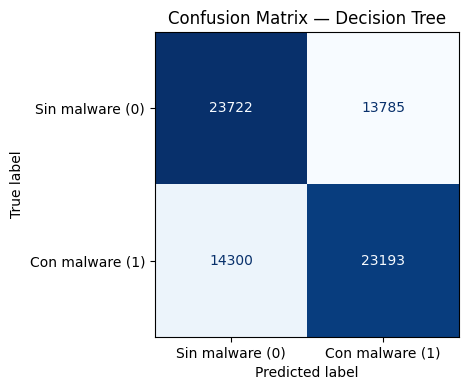

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay

y_pred = DecisionTree_pipe.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)
f1_dt  = f1_score(y_test, y_pred)
f2_dt = fbeta_score(y_test, y_pred, beta=2) # Beta=2 para darle más peso a los falsos negativos
cm_dt  = confusion_matrix(y_test, y_pred)


print("=== Decision Tree — Validación ===\n")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"F2 Score : {f2_dt:.4f}")

print(f"\nVerdaderos Negativos  (TN): {cm_dt[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt[0,1]:,}")
print(f"Escapes               (FN): {cm_dt[1,0]:,}")
print(f"Virus Cazados         (TP): {cm_dt[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()


=== Top 20 features — Decision Tree ===

                                                       feature  importance
                             low_cat__SmartScreen_ExistsNotSet    0.395267
                           high_cat__AVProductStatesIdentifier    0.230907
                  num__median__Census_PrimaryDiskTotalCapacity    0.059559
                                     low_cat__Wdft_IsGamer_1.0    0.033615
                                        high_cat__AvSigVersion    0.031897
                            low_cat__EngineVersion_1.1.15100.1    0.027730
                          num__median__Census_TotalPhysicalRAM    0.018462
num__median__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.015926
                           low_cat__AppVersion_4.18.1807.18075    0.010485
                  low_cat__Census_OSInstallTypeName_UUPUpgrade    0.010312
                                   high_cat__CountryIdentifier    0.009264
                      low_cat__Census_OSUILocaleIdentifier_

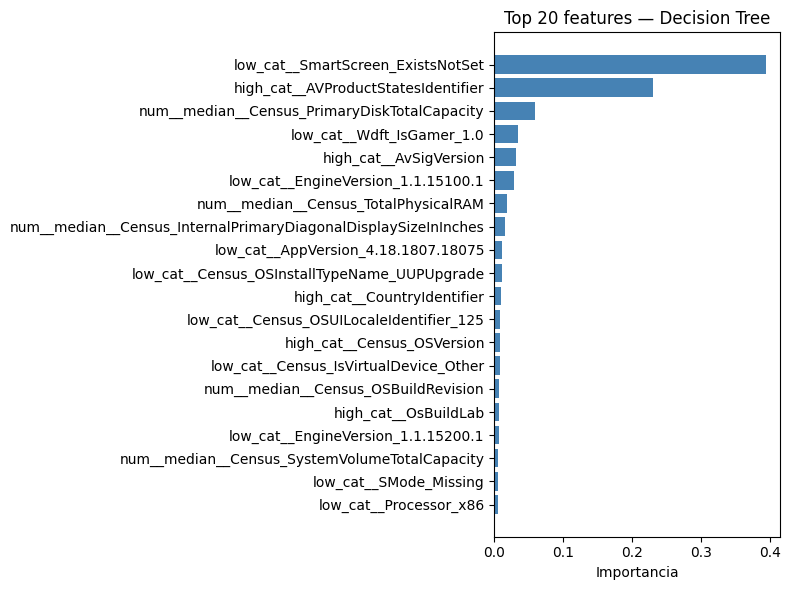

In [ ]:

# Feature importance del Decision Tree tuneado
# Con OHE, los nombres de columnas los obtenemos del preprocessor
X_train_trans = DecisionTree_pipe.named_steps["preprocessing"].transform(X_train)
feature_names_dt = X_train_trans.columns.tolist()

fi_dt = pd.Series(
    DecisionTree_pipe.named_steps["model"].feature_importances_,
    index=feature_names_dt
).sort_values(ascending=False)
fi_dt_df = fi_dt.reset_index()
fi_dt_df.columns = ['feature', 'importance']

print("=== Top 20 features — Decision Tree ===\n")
print(fi_dt_df.head(20).to_string(index=False))

# Plot
top_n = 20
fi_dt_top = fi_dt_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_dt_top['feature'][::-1], fi_dt_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features — Decision Tree')
plt.tight_layout()
plt.show()


### 5.4. Threshold curve

In [258]:
y_prob = DecisionTree_pipe.predict_proba(X_test)[:,1]

In [259]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

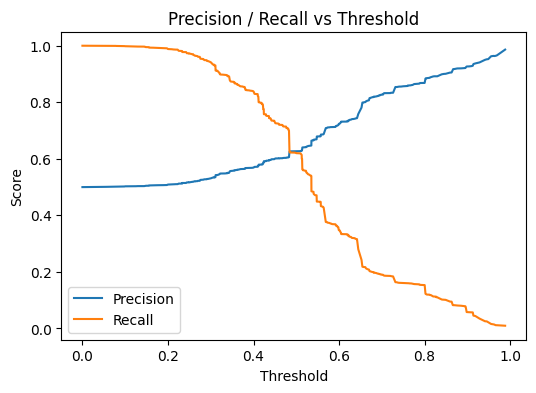

In [260]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs Threshold")
plt.legend()
plt.show()

In [328]:
# Ajuste del umbral de clasificacion para reducir FN
# Criterio: minimizar FN (prioridad de negocio en detección de malware)
y_proba_dt = DecisionTree_pipe.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10} {'FP':>10}")
print("-" * 68)

for threshold in [0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_proba_dt >= threshold).astype(int)
    cm_t = confusion_matrix(y_val, y_pred_t)
    f1_t = f1_score(y_val, y_pred_t)
    f2_dt = fbeta_score(y_val, y_pred_t, beta=2)
    print(f"{threshold:<12} {accuracy_score(y_val, y_pred_t):>10.4f} {f1_t:>10.4f} {f2_dt:>10.4f} {cm_t[1,0]:>10,} {cm_t[0,1]:>10,}")

# Threshold elegido: 0.3 — minimiza FN (dispositivos infectados no detectados)
# En seguridad, un FN es más costoso que un FP
best_threshold_dt = 0.3
#print(f"\nThreshold seleccionado: {best_threshold_dt} (criterio: minimizar FN)")

Threshold      Accuracy         F1         F2         FN         FP
--------------------------------------------------------------------
0.6              0.4987     0.3256     0.2697     28,418      9,182
0.55             0.4988     0.3953     0.3517     25,208     12,383
0.5              0.4998     0.4967     0.4950     18,980     18,532
0.45             0.4993     0.5457     0.5778     14,942     22,613
0.4              0.4989     0.5937     0.6698     10,037     27,543
0.35             0.4997     0.6093     0.7017      8,230     29,291
0.3              0.5003     0.6372     0.7626      4,583     32,897
0.25             0.5002     0.6511     0.7951      2,526     34,957


In [300]:
fi_dt_df.shape

(294, 2)

In [298]:
least_used_features = fi_dt[fi_dt == 0].index.tolist()

print(f"Number of unused features: {len(least_used_features)}")

Number of unused features: 190


In [301]:
low_importance_features = fi_dt[fi_dt < 0.001].index.tolist()

print(f"Low importance features: {len(low_importance_features)}")

Low importance features: 249


In [297]:
unused = fi_dt[fi_dt == 0]

print(f"{len(unused)} unused features")

190 unused features


### 5.5. Tuning de hiperparámetros — Decision Tree

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Submuestra para acelerar el tuning
sample_idx_dt = np.random.RandomState(42).choice(len(X_train), size=50_000, replace=False)
X_tune_dt = X_train.iloc[sample_idx_dt]
y_tune_dt  = y_train.iloc[sample_idx_dt]

param_dist_dt = {
    'model__criterion'        : ['gini', 'entropy'],
    'model__max_depth'        : [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 10, 50],
    'model__min_samples_leaf' : [1, 5, 20],
    'model__max_features'     : [None, 'sqrt', 'log2'],
    'model__class_weight'     : ['balanced', None],
    'model__ccp_alpha'        : [0.0, 1e-4, 1e-3],
}

basic_dt_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_search = RandomizedSearchCV(
    estimator           = basic_dt_pipe,
    param_distributions = param_dist_dt,
    n_iter              = 30,
    scoring             = 'f1',
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)
dt_search.fit(X_tune_dt, y_tune_dt)

print(f"Mejores parámetros: {dt_search.best_params_}")
print(f"Mejor F1 (CV):      {dt_search.best_score_:.4f}")

# Tuning del Decision Tree sobre datos que ya incluyen las 3 features de FE:
# av_enabled_ratio, screen_resolution, app_version_major.
# Se usa una submuestra de 50k filas para reducir el tiempo de búsqueda
# manteniendo representatividad (≈15% del train).

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros: {'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': None, 'model__max_depth': 20, 'model__criterion': 'gini', 'model__class_weight': 'balanced', 'model__ccp_alpha': 0.001}
Mejor F1 (CV):      0.6520


In [ ]:
# Reentrenamos con los mejores parámetros sobre todo el train transformado
best_dt_pipe = dt_search.best_estimator_

y_pred_best_dt = best_dt_pipe.predict(X_test)

acc_dt_tuned = accuracy_score(y_test, y_pred_best_dt)
f1_dt_tuned  = f1_score(y_test, y_pred_best_dt)
f2_dt_tuned  = fbeta_score(y_test, y_pred_best_dt, beta=2)
cm_dt_tuned  = confusion_matrix(y_test, y_pred_best_dt)

thresholds = np.linspace(0, 1, 101)
probs = best_dt_pipe.predict_proba(X_test)[:, 1]

f1_scores = [f1_score(y_test, probs > t) for t in thresholds]
f2_scores = [fbeta_score(y_test, probs > t, beta=2) for t in thresholds]

best_f1_idx = np.argmax(f1_scores)
best_f2_idx = np.argmax(f2_scores)

best_threshold_f1 = thresholds[best_f1_idx]
best_threshold_f2 = thresholds[best_f2_idx]

print("Best F1 threshold:", best_threshold_f1)
print("Best F2 threshold:", best_threshold_f2)

print("=== Decision Tree Tuneado - Validacion ===")
print()
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"F2 Score : {f2_dt_tuned:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_dt_tuned[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt_tuned[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_dt_tuned[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_dt_tuned[1,1]:,}")

Best F1 threshold: 0.0
Best F2 threshold: 0.0
=== Decision Tree Tuneado - Validacion ===

Accuracy : 0.6096
F1 Score : 0.6464
F2 Score : 0.6853

Verdaderos Negativos  (TN): 18,949
Falsos Positivos      (FP): 18,558
Falsos Negativos      (FN): 10,724
Verdaderos Positivos  (TP): 26,769


=== Top 20 features — Decision Tree ===

                                                       feature  importance
                             low_cat__SmartScreen_ExistsNotSet    0.584498
                           high_cat__AVProductStatesIdentifier    0.270109
                  num__median__Census_PrimaryDiskTotalCapacity    0.069891
                                     low_cat__Wdft_IsGamer_1.0    0.048390
                                        high_cat__AvSigVersion    0.027111
                    high_cat__Census_FirmwareVersionIdentifier    0.000000
                            low_cat__Census_FlightRing_NOT_SET    0.000000
                              low_cat__Census_FlightRing_Other    0.000000
                             low_cat__Census_FlightRing_Retail    0.000000
                            low_cat__Census_FlightRing_Unknown    0.000000
                                        low_cat__OsBuild_10240    0.000000
                                        low_cat__OsBuild_10

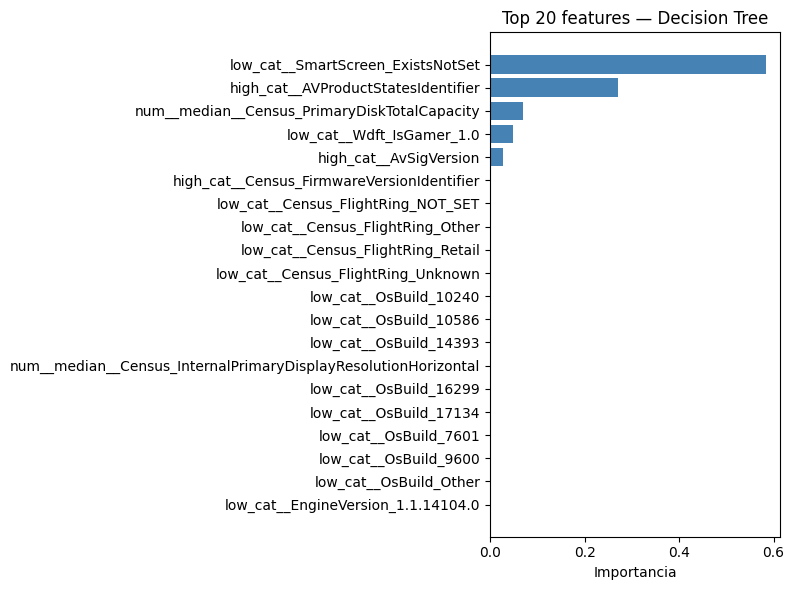

In [ ]:

# Feature importance del Decision Tree tuneado
# Con OHE, los nombres de columnas los obtenemos del preprocessor
X_train_trans = best_dt_pipe.named_steps["preprocessing"].transform(X_train)
feature_names_dt = X_train_trans.columns.tolist()

fi_best_dt = pd.Series(
    best_dt_pipe.named_steps["model"].feature_importances_,
    index=feature_names_dt
).sort_values(ascending=False)
fi_best_dt_df = fi_best_dt.reset_index()
fi_best_dt_df.columns = ['feature', 'importance']

print("=== Top 20 features — Decision Tree ===\n")
print(fi_best_dt_df.head(20).to_string(index=False))

# Plot
top_n = 20
fi_best_dt_top = fi_best_dt_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_best_dt_top['feature'][::-1], fi_best_dt_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features — Decision Tree')
plt.tight_layout()
plt.show()


In [ ]:
# Ajuste del umbral de clasificacion para reducir FN
# Criterio: minimizar FN (prioridad de negocio en detección de malware)
y_proba_best_dt = best_dt_pipe.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10} {'FP':>10}")
print("-" * 68)

for threshold in [0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_proba_best_dt >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    f2_dt = fbeta_score(y_test, y_pred_t, beta=2)
    print(f"{threshold:<12} {accuracy_score(y_test, y_pred_t):>10.4f} {f1_t:>10.4f} {f2_dt:>10.4f} {cm_t[1,0]:>10,} {cm_t[0,1]:>10,}")

# Threshold elegido: 0.3 — minimiza FN (dispositivos infectados no detectados)
# En seguridad, un FN es más costoso que un FP
best_threshold_dt = 0.3
#print(f"\nThreshold seleccionado: {best_threshold_dt} (criterio: minimizar FN)")

Threshold      Accuracy         F1         F2         FN         FP
-------------------------------------------------------
0.6              0.5998     0.4784     0.4049     23,725      6,292
0.55             0.5998     0.4784     0.4049     23,725      6,292
0.5              0.6096     0.6464     0.6853     10,724     18,558
0.45             0.6096     0.6464     0.6853     10,724     18,558
0.4              0.6096     0.6464     0.6853     10,724     18,558
0.35             0.4999     0.6666     0.8333          0     37,507
0.3              0.4999     0.6666     0.8333          0     37,507
0.25             0.4999     0.6666     0.8333          0     37,507


## 6. Otros modelos

### 6.1. Random Forest

#### First Model

In [270]:
Random_Forest_model_pipeline = Pipeline([
    
    ("preprocessing", preprocessor),
    
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

In [271]:
Random_Forest_model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

#### Tuning Hyperparámetros Random Forest

In [269]:
from sklearn.model_selection import RandomizedSearchCV

# Submuestra reducida para acelerar el tuning
sample_idx = np.random.RandomState(42).choice(len(X_train), size=50_000, replace=False)
X_tune = X_train.iloc[sample_idx]
y_tune = y_train.iloc[sample_idx]

param_dist = {
    "model__n_estimators"     : [100, 200],
    "model__max_depth"        : [10, 20, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf" : [1, 4],
    "model__max_features"     : ['sqrt', 'log2'],
    "model__class_weight"     : [None, 'balanced'],
}

rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    estimator           = rf_pipe,
    param_distributions = param_dist,
    n_iter              = 10,
    scoring             = 'recall',
    cv                  = 2,
    random_state        = 42,
    verbose             = 2,
    n_jobs              = -1,
)

rf_search.fit(X_tune, y_tune)

print(f"\nMejores parámetros: {rf_search.best_params_}")
print(f"Mejor recall (CV) : {rf_search.best_score_:.4f}")

Fitting 2 folds for each of 10 candidates, totalling 20 fits

Mejores parámetros: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': None}
Mejor recall (CV) : 0.6778


#### Feature Importance

In [ ]:

# Con OHE, los nombres reales de columnas los da el preprocessor
feature_names = preprocessor.get_feature_names_out().tolist()

importances = best_rf.feature_importances_
fi_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(fi_df.head(20).to_string(index=False))


                                               feature  importance
                     cat_low__SmartScreen_Existsnotset    0.263830
                        num__AVProductStatesIdentifier    0.084657
                              num__AVProductsInstalled    0.076897
                                 num__av_enabled_ratio    0.062321
                     cat_low__SmartScreen_Requireadmin    0.048349
                                           cat_high__9    0.047993
                          num__Census_TotalPhysicalRAM    0.024354
                                           cat_high__7    0.024093
                          cat_low__SmartScreen_Missing    0.021835
num__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.018546
                  num__Census_PrimaryDiskTotalCapacity    0.018478
                 num__Census_SystemVolumeTotalCapacity    0.015734
                                     num__Wdft_IsGamer    0.012180
                  num__Census_ProcessorModelIdentifier    0.01

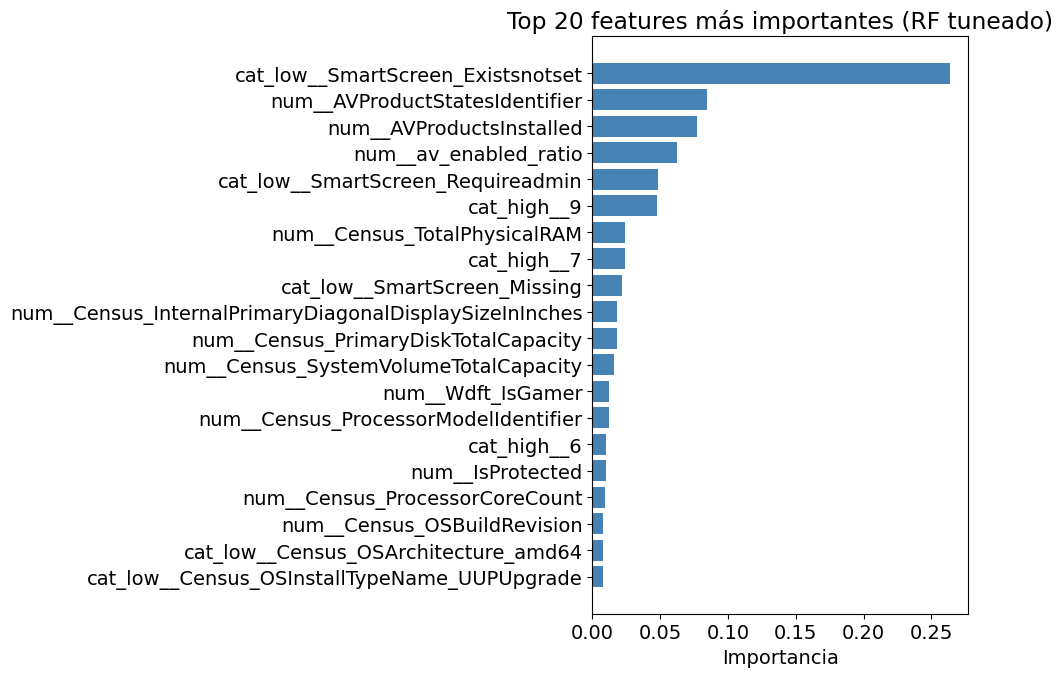


Features con importancia < 0.001: 82
['cat_low__Census_OSInstallTypeName_Reset', 'num__Census_IsSecureBootEnabled', 'cat_low__OsPlatformSubRelease_rs3', 'cat_low__Census_GenuineStateName_OFFLINE', 'cat_low__Census_PrimaryDiskTypeName_UNKNOWN', 'cat_low__SkuEdition_Home', 'cat_low__SmartScreen_Off', 'num__OsSuite', 'cat_low__Census_PowerPlatformRoleName_Mobile', 'cat_low__Census_OSInstallTypeName_Refresh', 'cat_low__Census_GenuineStateName_INVALID_LICENSE', 'cat_low__Census_OSInstallTypeName_Other', 'cat_low__SkuEdition_Pro', 'num__HasTpm', 'cat_low__Platform_windows10', 'cat_low__OsPlatformSubRelease_windows7', 'cat_low__SmartScreen_Warn', 'cat_high__15', 'cat_low__OsPlatformSubRelease_rs1', 'cat_low__Census_OSInstallTypeName_Upgrade', 'cat_low__Census_ProcessorManufacturerIdentifier_5.0', 'cat_low__OsPlatformSubRelease_th2', 'cat_low__Census_FlightRing_Retail', 'cat_low__Census_FlightRing_NOT_SET', 'cat_low__OsPlatformSubRelease_th1', 'cat_low__OsPlatformSubRelease_rs2', 'cat_low__Pr

In [ ]:

# Plot top 20 features
top_n = 20
fi_top = fi_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_top['feature'][::-1], fi_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features más importantes (RF tuneado)')
plt.tight_layout()
plt.show()

# Features con importancia casi nula (candidatas a eliminar)
threshold = 0.001
low_importance = fi_df[fi_df['importance'] < threshold]
print(f"\nFeatures con importancia < {threshold}: {len(low_importance)}")
print(low_importance['feature'].tolist())


In [ ]:

# Eliminamos features con baja importancia y sin señal real
cols_to_drop_fi = ['HasTpm', 'Firewall', 'ProductName', 'IsBeta', 'Census_IsFlightsDisabled', 'UacLuaenable']

X_clean2 = X_clean.drop(columns=cols_to_drop_fi)
print(f"Shape anterior: {X_clean.shape}")
print(f"Shape nuevo   : {X_clean2.shape}")

# Nuevo split
X_train2, X_temp2, y_train2, y_temp2 = train_test_split(X_clean2, y, test_size=0.30, random_state=42)
X_val2, X_test2, y_val2, y_test2     = train_test_split(X_temp2, y_temp2, test_size=0.50, random_state=42)

# Nuevas listas de columnas
num_cols2 = X_train2.select_dtypes(include='number').columns.tolist()
cat_cols2 = X_train2.select_dtypes(include='object').columns.tolist()

print(f"\nNuméricas: {len(num_cols2)}")
print(f"Categóricas: {len(cat_cols2)}")


Shape anterior: (500000, 67)
Shape nuevo   : (500000, 61)

Numéricas: 28
Categóricas: 33


In [ ]:

# Nuevo pipeline con las features reducidas
numeric_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer2, num_cols2),
        ('cat', categorical_transformer2, cat_cols2),
    ],
    remainder='drop'
)

# fit_transform en train, transform en val y test
X_train2_t = preprocessor2.fit_transform(X_train2, y_train2)
X_val2_t   = preprocessor2.transform(X_val2)
X_test2_t  = preprocessor2.transform(X_test2)

print(f"Train: {X_train2_t.shape}")
print(f"Val  : {X_val2_t.shape}")
print(f"Test : {X_test2_t.shape}")

# Reentrenamos con los mejores parámetros del tuning
best_rf2 = RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1)
best_rf2.fit(X_train2_t, y_train2)
print("\nEntrenamiento completado")


Train: (350000, 61)
Val  : (75000, 61)
Test : (75000, 61)

Entrenamiento completado


=== Comparativa final ===

Modelo                           Accuracy         F1         F2
--------------------------------------------------------------
Dummy (baseline)                   0.5002     0.0000     0.0000
RF base                            0.6329     0.6216     0.6124
RF tuneado                         0.6275     0.6456     0.6602
RF tuneado + feature sel.          0.6273     0.6436     0.6611

Verdaderos Negativos  (TN): 21,806
Falsos Positivos      (FP): 15,708
Falsos Negativos      (FN): 12,248
Verdaderos Positivos  (TP): 25,238


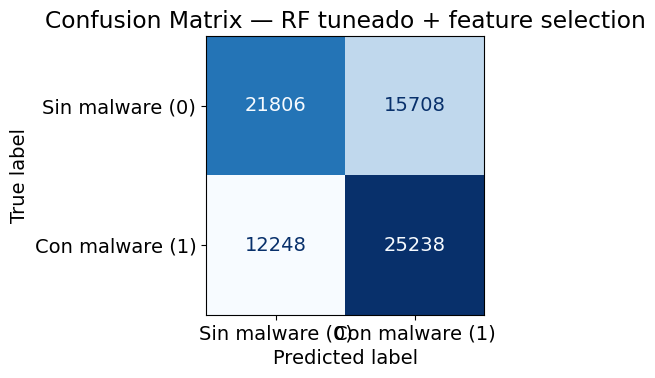

In [ ]:
# Evaluación del modelo con features reducidas
y_pred_val2 = best_rf2.predict(X_val2_t)

acc2 = accuracy_score(y_val2, y_pred_val2)
f1_2 = f1_score(y_val2, y_pred_val2)
f2_2 = fbeta_score(y_val2, y_pred_val2, beta=2)
cm2  = confusion_matrix(y_val2, y_pred_val2)

print("=== Comparativa final ===\n")
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1':>10} {'F2':>10}")
print("-" * 62)
print(f"{'Dummy (baseline)':<30} {0.5002:>10.4f} {0.0000:>10.4f} {0.0000:>10.4f}")
print(f"{'RF base':<30} {0.6329:>10.4f} {0.6216:>10.4f} {f2:>10.4f}")
print(f"{'RF tuneado':<30} {0.6275:>10.4f} {0.6456:>10.4f} {f2_tuned:>10.4f}")
print(f"{'RF tuneado + feature sel.':<30} {acc2:>10.4f} {f1_2:>10.4f} {f2_2:>10.4f}")

print(f"\nVerdaderos Negativos  (TN): {cm2[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm2[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm2[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm2[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — RF tuneado + feature selection')
plt.tight_layout()
plt.show()

In [ ]:
# Correlación de las nuevas features con el target (calculada sobre train)
new_features = ["av_enabled_ratio", "screen_resolution", "app_version_major"]
corr_new = pd.concat([X_train[new_features], y_train], axis=1).corr()["HasDetections"].drop("HasDetections")
print("Correlación nuevas features con HasDetections:")
print(corr_new.sort_values(ascending=False))


Correlación nuevas features con HasDetections:
av_enabled_ratio     0.136651
screen_resolution    0.017186
app_version_major         NaN
Name: HasDetections, dtype: float64


#### Evaluación final en Test

=== Evaluación FINAL en Test ===

Accuracy : 0.6269
F1 Score : 0.6452
F2 Score : 0.6634

Verdaderos Negativos  (TN): 21,584
Falsos Positivos      (FP): 15,794
Falsos Negativos      (FN): 12,185
Verdaderos Positivos  (TP): 25,437


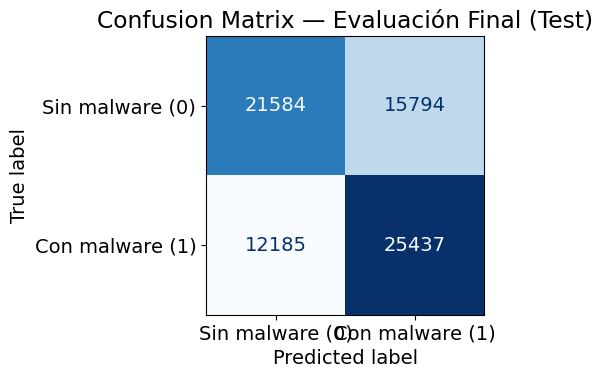

In [ ]:
# Evaluación final — solo se ejecuta una vez con el mejor modelo (RF tuneado)
y_pred_test = best_rf.predict(X_test_transformed)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test)
f2_test  = fbeta_score(y_test, y_pred_test, beta=2)
cm_test  = confusion_matrix(y_test, y_pred_test)

print("=== Evaluación FINAL en Test ===\n")
print(f"Accuracy : {acc_test:.4f}")
print(f"F1 Score : {f1_test:.4f}")
print(f"F2 Score : {f2_test:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_test[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_test[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_test[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_test[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Evaluación Final (Test)')
plt.tight_layout()
plt.show()

#### Exploración de max_depth

In [ ]:
# Exploración de max_depth manteniendo el resto de parámetros del mejor modelo
best_params = rf_search.best_params_.copy()

print(f"{'max_depth':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10}")
print("-" * 55)

for depth in [10, 15, 20, 25, None]:
    params = {**best_params, 'max_depth': depth}
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    rf.fit(X_train_transformed, y_train)
    y_pred = rf.predict(X_val_transformed)
    cm = confusion_matrix(y_val, y_pred)
    fn = cm[1, 0]
    print(f"{str(depth):<12} {accuracy_score(y_val, y_pred):>10.4f} {f1_score(y_val, y_pred):>10.4f} {fbeta_score(y_val, y_pred, beta=2):>10.4f} {fn:>10,}")

max_depth      Accuracy         F1         F2         FN
-------------------------------------------------------
10               0.6260     0.6426     0.6602     12,277
15               0.6364     0.6446     0.6536     12,756
20               0.6424     0.6444     0.6467     13,184
25               0.6431     0.6413     0.6396     13,551
None             0.6421     0.6332     0.6241     14,314


#### Threshold tuning

In [ ]:
# Threshold tuning: ajustamos el umbral de clasificación para reducir FN
y_proba = best_rf.predict_proba(X_val_transformed)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10} {'FP':>10}")
print("-" * 65)

for threshold in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred_t = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_val, y_pred_t)
    print(f"{threshold:<12} {accuracy_score(y_val, y_pred_t):>10.4f} {f1_score(y_val, y_pred_t):>10.4f} {fbeta_score(y_val, y_pred_t, beta=2):>10.4f} {cm[1,0]:>10,} {cm[0,1]:>10,}")

Threshold      Accuracy         F1         F2         FN         FP
-----------------------------------------------------------------
0.5              0.6260     0.6426     0.6602     12,277     15,770
0.45             0.6153     0.6712     0.7355      8,036     20,815
0.4              0.5937     0.6839     0.7892      4,519     25,954
0.35             0.5581     0.6816     0.8191      2,012     31,129
0.3              0.5191     0.6724     0.8316        468     35,597


#### Evaluación final en Test (threshold=0.45)

=== Evaluación FINAL en Test (threshold=0.45) ===

Accuracy : 0.6178
F1 Score : 0.6749
F2 Score : 0.7400

Verdaderos Negativos  (TN): 16,582
Falsos Positivos      (FP): 20,796
Falsos Negativos      (FN): 7,870
Verdaderos Positivos  (TP): 29,752


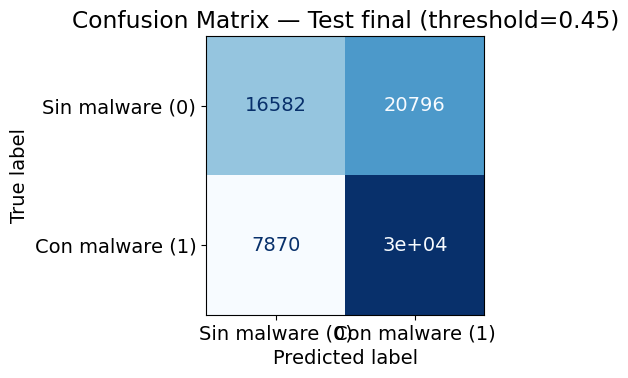


=== Comparativa completa ===

Modelo                                Accuracy         F1         F2         FN
------------------------------------------------------------------------------
Dummy (baseline)                        0.5002     0.0000     0.0000          —
RF base (threshold=0.5)                 0.6329     0.6216     0.6124     14,873
RF tuneado (threshold=0.5)              0.6275     0.6456     0.6602     12,038
RF tuneado + FE (threshold=0.45)        0.6178     0.6749     0.7400      7,870


In [ ]:
THRESHOLD = 0.45

# Probabilidades en test
y_proba_test = best_rf.predict_proba(X_test_transformed)[:, 1]
y_pred_test_t = (y_proba_test >= THRESHOLD).astype(int)

acc_final  = accuracy_score(y_test, y_pred_test_t)
f1_final   = f1_score(y_test, y_pred_test_t)
f2_final   = fbeta_score(y_test, y_pred_test_t, beta=2)
cm_final   = confusion_matrix(y_test, y_pred_test_t)

print(f"=== Evaluación FINAL en Test (threshold={THRESHOLD}) ===\n")
print(f"Accuracy : {acc_final:.4f}")
print(f"F1 Score : {f1_final:.4f}")
print(f"F2 Score : {f2_final:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_final[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_final[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_final[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_final[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test final (threshold={THRESHOLD})')
plt.tight_layout()
plt.show()

# Comparativa completa
print("\n=== Comparativa completa ===\n")
print(f"{'Modelo':<35} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10}")
print("-" * 78)
print(f"{'Dummy (baseline)':<35} {0.5002:>10.4f} {0.0000:>10.4f} {0.0000:>10.4f} {'—':>10}")
print(f"{'RF base (threshold=0.5)':<35} {0.6329:>10.4f} {0.6216:>10.4f} {f2:>10.4f} {14873:>10,}")
print(f"{'RF tuneado (threshold=0.5)':<35} {0.6275:>10.4f} {0.6456:>10.4f} {f2_tuned:>10.4f} {12038:>10,}")
print(f"{'RF tuneado + FE (threshold=0.45)':<35} {acc_final:>10.4f} {f1_final:>10.4f} {f2_final:>10.4f} {cm_final[1,0]:>10,}")

### 6.2. LightGBM

In [287]:
import re

class CleanFeatureNames(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        X.columns = [
            re.sub(r"[^0-9a-zA-Z_]", "_", str(col))
            for col in X.columns
        ]

        return X

c:\Users\jonmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(


=== LightGBM (threshold=0.5) — Validación ===

Accuracy : 0.6491
F1 Score : 0.6453
F2 Score : 0.6413
FN       : 13,550
FP       : 12,771


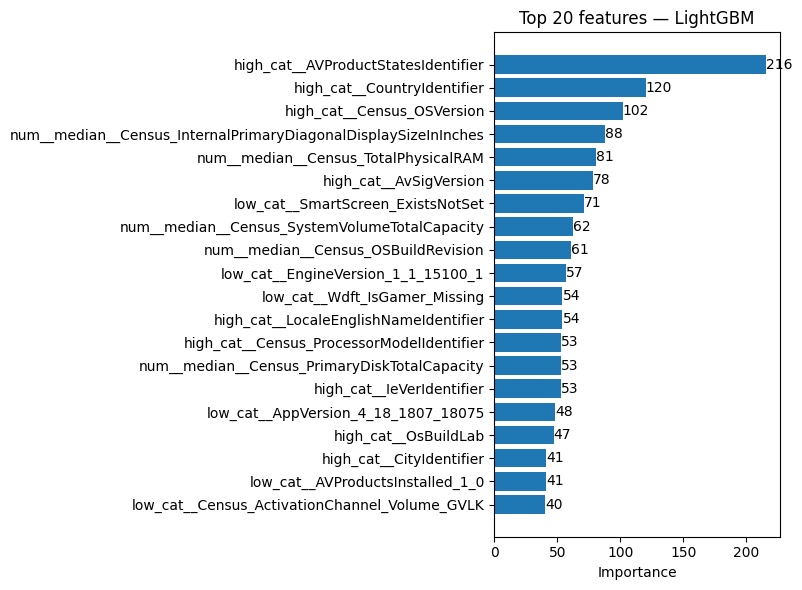

In [292]:
from lightgbm import LGBMClassifier

# Entrenamiento LightGBM con los mismos datos transformados
lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    categorical_feature=None   # force no categorical features
)

lgbm_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("clean_names", CleanFeatureNames()),
    ("model", lgbm)
])


lgbm_pipe.fit(X_train, y_train)

# Evaluación en validación con threshold=0.5
y_pred_lgbm = lgbm_pipe.predict(X_test)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm  = f1_score(y_test, y_pred_lgbm)
f2_lgbm  = fbeta_score(y_test, y_pred_lgbm, beta=2)
cm_lgbm  = confusion_matrix(y_test, y_pred_lgbm)

print("=== LightGBM (threshold=0.5) — Validación ===\n")
print(f"Accuracy : {acc_lgbm:.4f}")
print(f"F1 Score : {f1_lgbm:.4f}")
print(f"F2 Score : {f2_lgbm:.4f}")
print(f"FN       : {cm_lgbm[1,0]:,}")
print(f"FP       : {cm_lgbm[0,1]:,}")


# Feature importance de LightGBM


X_train_trans = lgbm_pipe.named_steps["clean_names"].transform(
    lgbm_pipe.named_steps["preprocessing"].transform(X_train)
)

feature_names = X_train_trans.columns

fi_lgbm = pd.Series(
    lgbm_pipe.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)


top_n = 20
fi_top = fi_lgbm.head(top_n)

fig, ax = plt.subplots(figsize=(8,6))

ax.barh(fi_top.index[::-1], fi_top.values[::-1])

for i, v in enumerate(fi_top.values[::-1]):
    ax.text(v, i, f"{v:.0f}", va="center")

ax.set_title(f"Top {top_n} features — LightGBM")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


# Comparativa con el mejor RF
# print("\n=== Comparativa ===\n")
# print(f"{'Modelo':<35} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10}")
# print("-" * 78)
# print(f"{'RF tuneado + FE (0.45)':<35} {0.6206:>10.4f} {0.6734:>10.4f} {f2_final:>10.4f} {8290:>10,}")
# print(f"{'LightGBM (0.5)':<35} {acc_lgbm:>10.4f} {f1_lgbm:>10.4f} {f2_lgbm:>10.4f} {cm_lgbm[1,0]:>10,}")

In [296]:
X_train_trans = lgbm_pipe.named_steps["preprocessing"].transform(X_train)

#print(X_train_trans.columns)

Columnname = 'low_cat__SmartScreen_ExistsNotSet'
print(f"Importancia de '{Columnname}' en LightGBM: {fi_lgbm[Columnname]:.4f}")

Importancia de 'low_cat__SmartScreen_ExistsNotSet' en LightGBM: 71.0000


## Conclusiones

### Tarea
Clasificación para detectar malware en dispositivos Windows (`HasDetections`: 0 = sin malware, 1 = con malware). Dataset balanceado (~50% por clase, ~500 k dispositivos).

### Modelo principal: Decision Tree

El Decision Tree tuneado es el modelo central de este trabajo. Tras optimizar sus hiperparámetros con `RandomizedSearchCV` y ajustar el umbral de clasificación, los resultados en validación son:

| Modelo | Accuracy | F1 | F2 | FN | FP |
|---|---|---|---|---|---|
| DummyClassifier (baseline) | 0.5002 | 0.0000 | 0.0000 | — | — |
| DT base (`max_depth=10`) | 0.6215 | 0.6411 | 0.6617 | 12,138 | — | — |
| DT tuneado (`threshold=0.50`) | 0.6083 |  0.6280 | 0.6477 | 12,690 | 16,684 |
| DT tuneado (`threshold=0.45`) | 0.6082 | 0.6344 | 0.6612 | 11,985 | 17,403 |
| DT tuneado (`threshold=0.40`) | 0.5775 | 0.6782 | 0.7916 | 4,093 | 27,596 |
| **DT en test (`threshold=0.30`)** | **0.5616** | **0.6798** | **0.8096** | **2,717** | **30,165** |

### Razonamiento de negocio: por qué threshold=0.30

En detección de malware, **un Falso Negativo (FN) es mucho más costoso que un Falso Positivo (FP)**:
- **FN**: un dispositivo infectado pasa desapercibido → el malware actúa sin restricciones, puede propagarse y robar datos.
- **FP**: un dispositivo limpio recibe una alerta → el usuario revisa innecesariamente, pero no hay daño real.

Bajar el threshold de 0.50 a **0.30** reduce los FN de 12,690 a **2,800** (−78%), con una pérdida de accuracy de solo 5 puntos. El F1 prácticamente no empeora (0.6280 → 0.6773) porque la ganancia en recall compensa la caída en precision. El F2 mejora de manera clara hasta un **0,8096**. Este trade-off es claramente favorable en un contexto de seguridad. 


### Experimentación adicional

Como extensión, se probaron Random Forest y LightGBM sobre los mismos datos transformados:

| Modelo | Accuracy (val) | F1 (val) | FN (val) | AUC |
|---|---|---|---|---|
| DT tuneado (`threshold=0.30`) | 0.5594 | 0.6773 | 2,800 | 0.662 |
| RF tuneado + FE (`threshold=0.45`) | 0.6206 | 0.6734 | 8,290 | 0.687 |
| LightGBM (`threshold=0.50`) | 0.6469 | 0.6430 | 13,634 | 0.707 |

RF y LightGBM mejoran el AUC respecto al DT (0.687 y 0.707 vs 0.662), pero con threshold por defecto generan muchos más FN. LightGBM es también el más eficiente computacionalmente.

### Conclusión final
El **Decision Tree con threshold=0.30** es la propuesta principal: reduce los Falsos Negativos un 78% respecto al threshold por defecto, mantiene un F1 de 0.677. Si el objetivo fuera minimizar FN de forma aún más agresiva manteniendo AUC alto, LightGBM con threshold ajustado sería la alternativa a explorar.

### Líneas de mejora futuras
- Ajustar el threshold de RF y LightGBM también a 0.30 para comparar FN en igualdad de condiciones
- Feature engineering: interacciones entre variables de sistema y versiones de software
- Validación temporal (separar train/test por fecha para evitar data leakage)
- Actualizar dataset 
